<a href="https://colab.research.google.com/github/Bloop15/DL-2026-2027/blob/main/LSTM_vs_ESN_TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Implement LSTM networks and explore their benefits over standard RNNs.
# Build and train an LSTM network for a time series prediction problem, comparing it with Echo State Networks and other gated RNNs.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [4]:
class ESN:

    def __init__(self,n_inputs,n_outputs,n_reservoir=100,spectral_radius=0.95,sparsity=0.1,random_state=None):

        self.n_inputs= n_inputs
        self.n_outputs= n_outputs
        self.n_reservoir= n_reservoir
        self.spectral_radius= spectral_radius
        self.sparsity= sparsity

        self.random_state= np.random.RandomState(random_state)

        self._Win= self.random_state.rand(self.n_reservoir,self.n_inputs)-0.5
        W= self.random_state.rand(self.n_reservoir,self.n_reservoir)-0.5
        W[self.random_state.rand(*W.shape)>self.sparsity]= 0
        radius= np.max(np.abs(np.linalg.eigvals(W)))
        self._W= W*(self.spectral_radius / radius)

    def _update(self,state,input_signal):

        pre_activation= (np.dot(self._Win, input_signal)+np.dot(self._W, state))
        return np.tanh(pre_activation)

    def fit(self,X,y):

        states= np.zeros((X.shape[0], self.n_reservoir))
        state= np.zeros(self.n_reservoir)

        for t in range(X.shape[0]):
            state= self._update(state, X[t])
            states[t]= state

        self._Wout= np.dot(np.linalg.pinv(states), y)

    def predict(self, X):

        predictions= []
        state= np.zeros(self.n_reservoir)

        for t in range(X.shape[0]):

            state= self._update(state, X[t])
            y_pred= np.dot(state, self._Wout)
            predictions.append(y_pred)

        return np.array(predictions)

In [5]:
time= np.arange(0, 100, 0.1)
series= np.sin(time)

def create_dataset(data, window=20):

    X, y= [], []

    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])

    return np.array(X), np.array(y)

In [9]:
window_size= 20
X, y= create_dataset(series, window=window_size)
X_lstm= X.reshape((X.shape[0], window_size, 1))

split= int(0.8*len(X))
X_train= X_lstm[:split]
X_test= X_lstm[split:]
y_train= y[:split]
y_test= y[split:]

In [10]:
lstm= Sequential([
    LSTM(50, input_shape=(window_size, 1)),
    Dense(1)
])

lstm.compile(optimizer='adam',loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
lstm.fit(X_train,y_train,epochs=10,batch_size=32,verbose=1)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2758
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0609
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.2706e-04
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.6676e-04
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8933e-04
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2647e-04
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6622e-04
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2105e-04
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.1347e-05


In [12]:
lstm_pred= lstm.predict(X_test).flatten()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [13]:
X_train_esn= X[:split]
X_test_esn= X[split:]

esn= ESN(n_inputs=window_size,n_outputs=1,n_reservoir=100,random_state=42)

In [17]:
esn.fit(X_train_esn, y_train)
esn_pred= esn.predict(X_test_esn)

print("LSTM MSE:", mean_squared_error(y_test, lstm_pred))
print("ESN MSE:", mean_squared_error(y_test, esn_pred))

LSTM MSE: 7.433889136072735e-05
ESN MSE: 2.5677275838620616e-05


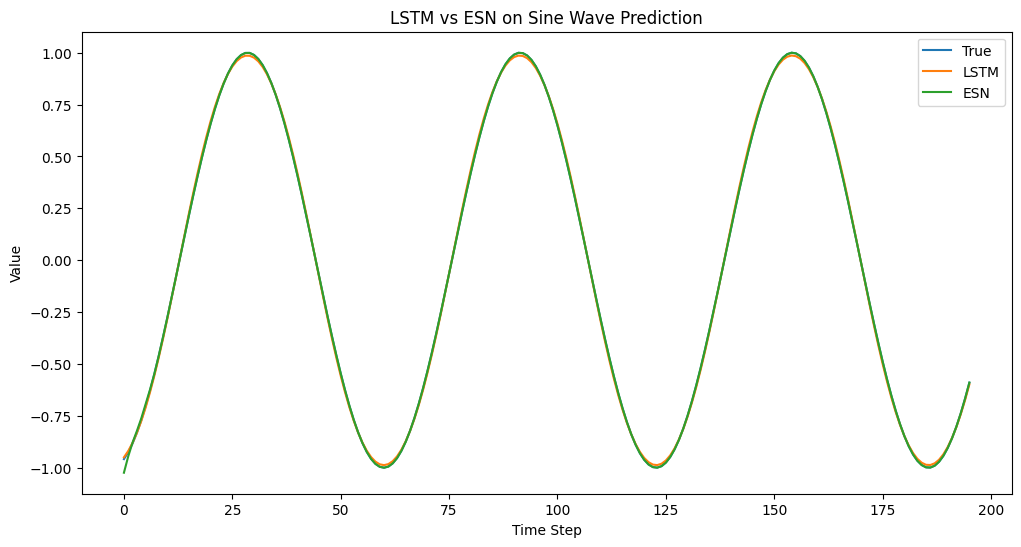

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='True')
plt.plot(lstm_pred, label='LSTM')
plt.plot(esn_pred, label='ESN')
plt.legend()
plt.title("LSTM vs ESN on Sine Wave Prediction")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.show()